# Лабораторная работа: Прогнозирование заказов такси

**Описание**

Компания собрала исторические данные о заказах такси в аэропортах.
Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час.

**Цель**

Построить модель для предсказания количество заказов такси на следующий час.

**Условия и ограничения**

* Ресемплирование выполняется по одному часу.
* Тестовая выборка не должна превышать $10\%$ от исходных данных.
* Значение метрики RMSE на тестовой выборке не должно превышать значения $48$.

**Описание данных**

Данные находятся в файле `https://code.s3.yandex.net/datasets/taxi.csv`:
* `datetime` - дата и время
* `num_orders` - количество заказов такси

**План работы**

1. Подготовить данные
2. Выполлнить анализ данных
3. Построить модели
4. Выполнить тестирование модели

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics import tsaplots

## Подготовка

In [2]:
data = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv',
                   index_col=[0], parse_dates=[0]).resample('h').sum()
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [3]:
data.index.is_monotonic_increasing

True

## Анализ

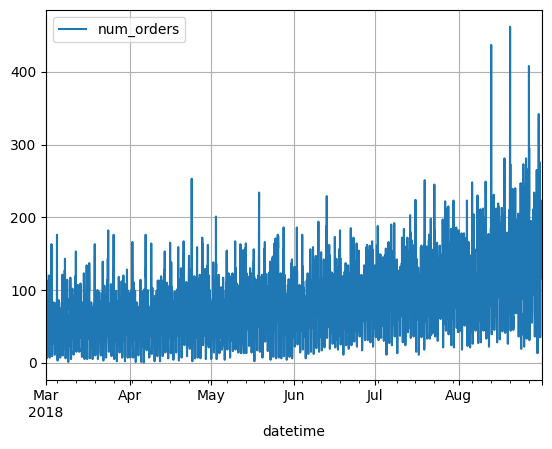

In [4]:
data.plot()
plt.grid()
plt.show()

In [5]:
data.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


## Обучение

### Предсказание предыдущим значением

In [6]:
train, test = train_test_split(data, shuffle=False, test_size=0.1)

print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2018-03-01 00:00:00 2018-08-13 13:00:00
2018-08-13 14:00:00 2018-08-31 23:00:00


In [7]:
pred_previous = test.shift(1)
pred_previous.iloc[0] = train.iloc[-1]

### ARIMA

In [8]:
adfuller(data['num_orders'], autolag='AIC')

(np.float64(-3.0689242890279553),
 np.float64(0.02894005140261296),
 30,
 4385,
 {'1%': np.float64(-3.431842162413052),
  '5%': np.float64(-2.8621993540813637),
  '10%': np.float64(-2.567120978470452)},
 np.float64(41728.71357827463))

In [9]:
adfuller(data['num_orders'].diff(1).dropna(), autolag='AIC')

(np.float64(-15.793234257410752),
 np.float64(1.095877674650304e-28),
 31,
 4383,
 {'1%': np.float64(-3.431842843698785),
  '5%': np.float64(-2.8621996550511697),
  '10%': np.float64(-2.56712113869159)},
 np.float64(41720.139669637894))

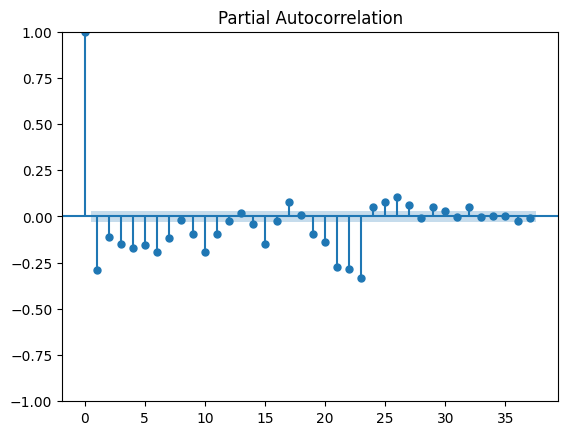

In [10]:
fig = tsaplots.plot_pacf(data['num_orders'].diff(1).dropna())
plt.show() # p = 1, временной лаг 1 по значениям

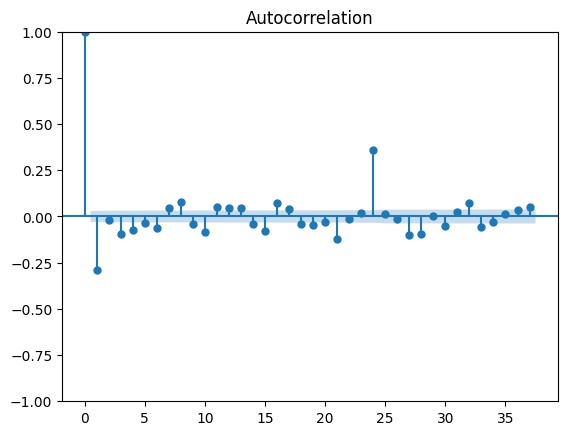

In [11]:
fig = tsaplots.plot_acf(data['num_orders'].diff(1).dropna())
plt.show() # q = 1, временной лаг 1 по ошибкам; явная сезонность по суткам

In [12]:
model = SARIMAX(train['num_orders'],
                order=(1,1,1),
                seasonal_order=(1,1,1,24)).fit()
pred_sarimax = model.predict(start=test.index[0], end=test.index[-1])

### Линейная регрессия

In [13]:
def make_features(data, max_lag):
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)
    data[f'lag_24'] = data['num_orders'].shift(24)
    data[f'lag_168'] = data['num_orders'].shift(168)
    data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)
    return data

make_features(data, 6)
data.head()

,num_orders,month,day,dayofweek,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_24,lag_168,is_weekend
datetime,,,,,,,,,,,,,
2018-03-01 00:00:00,124,3,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2018-03-01 01:00:00,85,3,1,3,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2018-03-01 02:00:00,71,3,1,3,85.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN,0
2018-03-01 03:00:00,66,3,1,3,71.0,85.0,124.0,NaN,NaN,NaN,NaN,NaN,0
2018-03-01 04:00:00,43,3,1,3,66.0,71.0,85.0,124.0,NaN,NaN,NaN,NaN,0


In [14]:
train, test = train_test_split(data, shuffle=False, test_size=0.1)
train = train.dropna()

features_train = train.drop('num_orders', axis=1)
target_train = train['num_orders']

features_test = test.drop('num_orders', axis=1)
target_test = test['num_orders']

model = LinearRegression()
model.fit(features_train, target_train)

pred_linreg = model.predict(features_test)

## Тестирование

In [15]:
def evaluate(predictions):
    rmse = mean_squared_error(test['num_orders'], predictions) ** 0.5
    plt.title(f'RMSE: {rmse:.2f}')
    plt.plot(test.index, test['num_orders'], label='Тестовая выборка')
    plt.plot(test.index, predictions, label='Предсказания')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=45)
    plt.show()

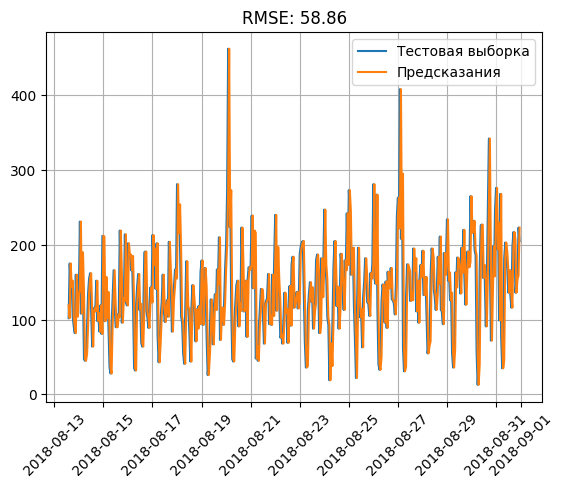

In [16]:
evaluate(pred_previous)

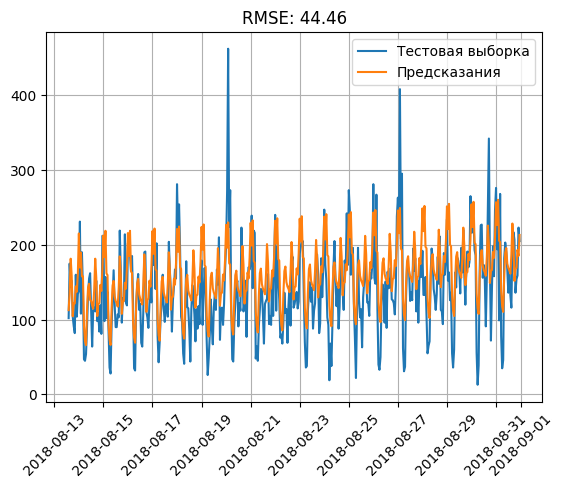

In [17]:
evaluate(pred_sarimax)

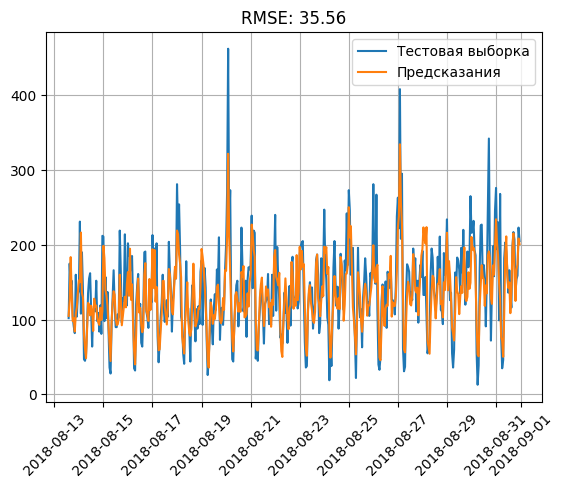

In [18]:
evaluate(pred_linreg)